# Assignment 3 — Cancer mutations in a Boolean network


Mutated versions of the cell regulatory network from the Boolean Networks practical:

- **Mutation A — p53 knockout**: `p53 = False` (always OFF)
- **Mutation B — MYC amplification**: `MYC = True` (always ON)

Each is compared against the unmutated network on the three practical scenarios and on the
full 256-state attractor analysis. Mutations C and D are commented-out slots in `MUTATIONS`;
adding one is a single line and every analysis picks it up.

**How to run**: `pip install -r requirements.txt`, then run all cells top to bottom.

In [13]:
# Setup and required libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import seaborn as sns
from itertools import product
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Network and mutations

```
DNA_damage = INPUT (constant)      MDM2   = MYC
p21        = p53                   p53    = DNA_damage AND (NOT MDM2)
MYC        = (NOT p53) AND (NOT p21)   Growth = CDK2 AND MYC AND (NOT p53)
CDK2       = MYC AND (NOT p21) AND (NOT p53)   Death = p53 AND DNA_damage AND (NOT Growth)
```

A mutation replaces one rule with a constant: the node stops listening to its regulators.

In [14]:
class BooleanNetwork:
    """Synchronous Boolean network (from the practical, unchanged apart from a quiet flag)."""

    def __init__(self, node_names):
        self.nodes = {name: 0 for name in node_names}
        self.rules = {}
        self.history = []
        self.graph = nx.DiGraph()
        self.graph.add_nodes_from(node_names)

    def add_rule(self, target_node, rule_function, rule_description=""):
        """Add (or replace) the Boolean rule for one node."""
        self.rules[target_node] = {'function': rule_function,
                                   'description': rule_description}

    def set_state(self, **kwargs):
        for node, value in kwargs.items():
            if node in self.nodes:
                self.nodes[node] = int(bool(value))

    def get_state_vector(self):
        """Current state as a list, in sorted node order."""
        return [self.nodes[node] for node in sorted(self.nodes.keys())]

    def update_synchronous(self):
        """Update every node at once from the current state."""
        new_state = {}
        for node in self.nodes:
            if node in self.rules:
                new_state[node] = int(self.rules[node]['function'](self.nodes))
            else:
                new_state[node] = self.nodes[node]
        self.nodes = new_state
        self.history.append(self.get_state_vector())

    def simulate(self, steps=10, record_history=True, quiet=False):
        """Run the network forward, stopping early at a steady state."""
        if record_history:
            self.history = [self.get_state_vector()]
        for step in range(steps):
            self.update_synchronous()
            if len(self.history) >= 2 and self.history[-1] == self.history[-2]:
                if not quiet:
                    print(f"   Reached steady state after {step + 1} steps")
                break
        return np.array(self.history)

In [15]:
NODES = ['DNA_damage', 'p53', 'MYC', 'CDK2', 'MDM2', 'p21', 'Growth', 'Death']
NODE_NAMES = sorted(NODES)          # the order used by get_state_vector()

# Wild-type rules, kept in one place so every network is built from the same source.
BASE_RULES = [
    ('DNA_damage', lambda s: s['DNA_damage'],                                     "DNA_damage = INPUT (constant)"),
    ('p21',        lambda s: s['p53'],                                            "p21 = p53"),
    ('MYC',        lambda s: (not s['p53']) and (not s['p21']),                   "MYC = (NOT p53) AND (NOT p21)"),
    ('CDK2',       lambda s: s['MYC'] and (not s['p21']) and (not s['p53']),      "CDK2 = MYC AND (NOT p21) AND (NOT p53)"),
    ('MDM2',       lambda s: s['MYC'],                                            "MDM2 = MYC"),
    ('p53',        lambda s: s['DNA_damage'] and not s['MDM2'],                   "p53 = DNA_damage AND (NOT MDM2)"),
    ('Growth',     lambda s: s['CDK2'] and s['MYC'] and (not s['p53']),           "Growth = CDK2 AND MYC AND (NOT p53)"),
    ('Death',      lambda s: s['p53'] and s['DNA_damage'] and (not s['Growth']),  "Death = p53 AND DNA_damage AND (NOT Growth)"),
]

# A mutation is a list of rule overrides applied on top of BASE_RULES.
# To add Mutation C or D, fill in the empty list - nothing else needs to change.
MUTATIONS = {
    'Normal': [],
    'A: p53 knockout': [
        ('p53', lambda s: False, "p53 = BROKEN (always OFF)"),
    ],
    'B: MYC amplification': [
        ('MYC', lambda s: True, "MYC = AMPLIFIED (always ON)"),
    ],
    'C: MDM2 overexpression': [
        ('MDM2', lambda s: True, "MDM2 = OVEREXPRESSED (always ON)")],
    'D: p21 knockout': [
    ('p21', lambda s: False, "p21 = BROKEN (always OFF)"),
    ],
}


def build_network(mutation='Normal', extra_overrides=None):
    """
    Build a fresh BooleanNetwork with the wild-type rules, then apply a mutation.

    Parameters
    ----------
    mutation : str
        Key into MUTATIONS.
    extra_overrides : list of (node, function, description), optional
        Further rule replacements applied last. Used in Part 3 to simulate a drug
        on top of a mutation.

    Returns
    -------
    BooleanNetwork
    """
    net = BooleanNetwork(NODES)
    for node, fn, desc in BASE_RULES:
        net.add_rule(node, fn, desc)
    for node, fn, desc in MUTATIONS[mutation]:
        net.add_rule(node, fn, desc)
    for node, fn, desc in (extra_overrides or []):
        net.add_rule(node, fn, desc)
    return net


for name in MUTATIONS:
    net = build_network(name)
    changed = [d for n, f, d in MUTATIONS[name]]
    print(f"{name:24s} -> {changed if changed else 'wild-type rules'}")

Normal                   -> wild-type rules
A: p53 knockout          -> ['p53 = BROKEN (always OFF)']
B: MYC amplification     -> ['MYC = AMPLIFIED (always ON)']
C: MDM2 overexpression   -> ['MDM2 = OVEREXPRESSED (always ON)']
D: p21 knockout          -> ['p21 = BROKEN (always OFF)']


## 2. Wiring and feedback loops

Edges are derived from the rules rather than written by hand, so the diagram cannot drift from
the code: each source is flipped across all 256 states and the resulting change in the target
is recorded as activation or inhibition. A loop's sign is the product of its edge signs —
positive loops give bistability, negative loops give homeostasis.

In [16]:
def influence_graph(net):
    """
    Derive the signed influence graph from a network's rules.

    An edge source -> target is added when flipping `source` changes the value that
    `target`'s rule returns for at least one of the 256 states. The sign records the
    direction of that change.
    """
    g = nx.DiGraph()
    g.add_nodes_from(NODE_NAMES)

    for target in NODE_NAMES:
        rule = net.rules[target]['function']
        for source in NODE_NAMES:
            activates = inhibits = False
            for bits in product([0, 1], repeat=len(NODE_NAMES)):
                state = dict(zip(NODE_NAMES, bits))
                if state[source] != 0:
                    continue
                off = int(bool(rule(state)))
                state[source] = 1
                on = int(bool(rule(state)))
                if on > off:
                    activates = True
                elif on < off:
                    inhibits = True
            if activates or inhibits:
                sign = 1 if activates and not inhibits else (-1 if inhibits and not activates else 0)
                g.add_edge(source, target, sign=sign)
    return g


normal_graph = influence_graph(build_network('Normal'))

print("Signed edges of the wild-type network:")
for u, v, d in sorted(normal_graph.edges(data=True)):
    arrow = {1: '-->  activates', -1: '--|  inhibits', 0: '-?-  mixed'}[d['sign']]
    print(f"   {u:11s} {arrow:18s} {v}")

print("\nFeedback loops (sign = product of edge signs):")
loops = [c for c in nx.simple_cycles(normal_graph) if len(c) > 1]
for loop in sorted(loops, key=len):
    signs = [normal_graph[loop[i]][loop[(i + 1) % len(loop)]]['sign'] for i in range(len(loop))]
    total = int(np.prod(signs))
    kind = 'POSITIVE (bistable switch)' if total > 0 else 'NEGATIVE (homeostatic)'
    print(f"   {' -> '.join(loop)} -> {loop[0]:11s}  {kind}")

Signed edges of the wild-type network:
   CDK2        -->  activates     Growth
   DNA_damage  -->  activates     DNA_damage
   DNA_damage  -->  activates     Death
   DNA_damage  -->  activates     p53
   Growth      --|  inhibits      Death
   MDM2        --|  inhibits      p53
   MYC         -->  activates     CDK2
   MYC         -->  activates     Growth
   MYC         -->  activates     MDM2
   p21         --|  inhibits      CDK2
   p21         --|  inhibits      MYC
   p53         --|  inhibits      CDK2
   p53         -->  activates     Death
   p53         --|  inhibits      Growth
   p53         --|  inhibits      MYC
   p53         -->  activates     p21

Feedback loops (sign = product of edge signs):
   MYC -> MDM2 -> p53 -> MYC          POSITIVE (bistable switch)
   MYC -> MDM2 -> p53 -> p21 -> MYC          POSITIVE (bistable switch)


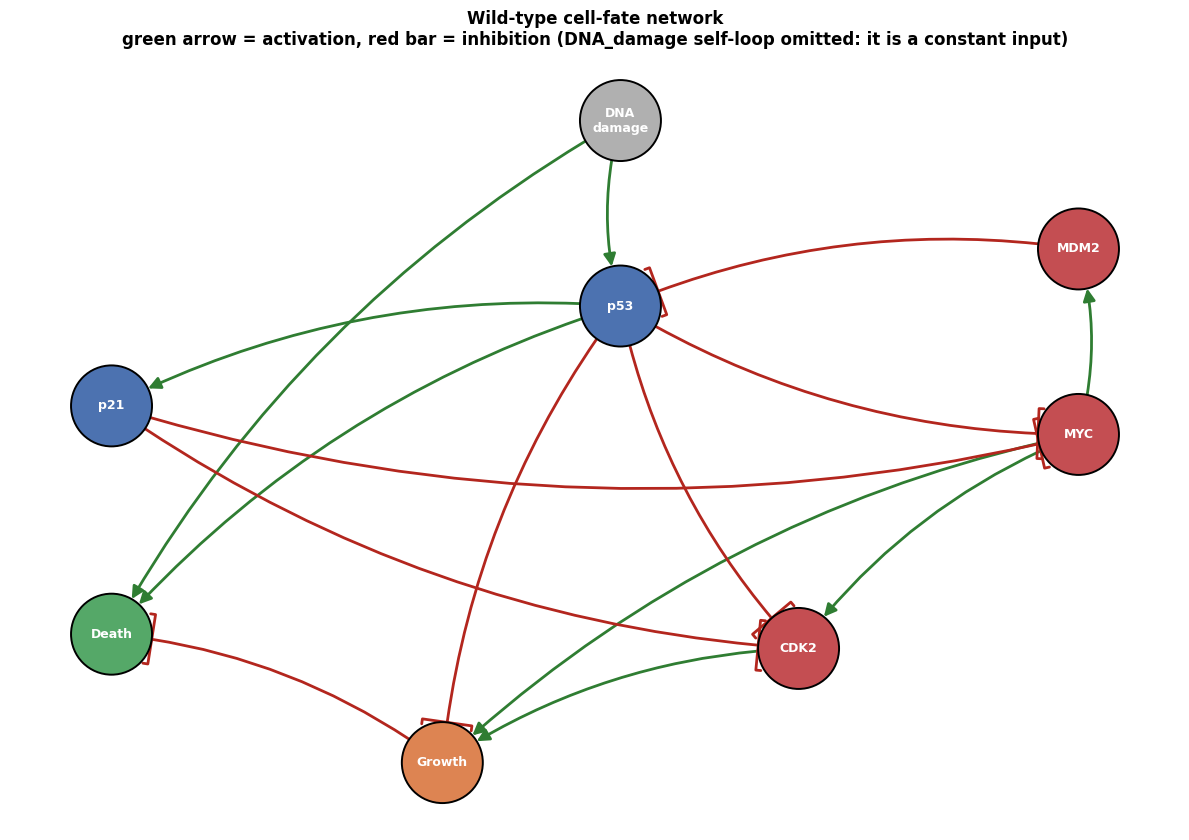

In [17]:
# Draw the wild-type wiring diagram.
fig, ax = plt.subplots(figsize=(12, 8.5))

pos = {
    'DNA_damage': (0.0, 1.0), 'p53': (0.0, 0.35), 'p21': (-1.0, 0.0),
    'MYC': (0.9, -0.1), 'MDM2': (0.9, 0.55), 'CDK2': (0.35, -0.85),
    'Growth': (-0.35, -1.25), 'Death': (-1.0, -0.8),
}
role_colour = {
    'DNA_damage': '#b0b0b0', 'p53': '#4C72B0', 'p21': '#4C72B0',
    'MYC': '#C44E52', 'MDM2': '#C44E52', 'CDK2': '#C44E52',
    'Growth': '#DD8452', 'Death': '#55A868',
}

nx.draw_networkx_nodes(normal_graph, pos, ax=ax, node_size=3400,
                       node_color=[role_colour[n] for n in normal_graph.nodes()],
                       edgecolors='black', linewidths=1.4)
nx.draw_networkx_labels(normal_graph, pos, ax=ax, font_size=9, font_weight='bold',
                        font_color='white',
                        labels={n: n.replace('_', '\n') for n in normal_graph.nodes()})

# The DNA_damage self-loop just encodes "constant input"; drawing it adds clutter.
for sign, colour, style in [(1, '#2f7d32', '-|>'), (-1, '#b3261e', '-[')]:
    edges = [(u, v) for u, v, d in normal_graph.edges(data=True)
             if d['sign'] == sign and u != v]
    nx.draw_networkx_edges(normal_graph, pos, edgelist=edges, ax=ax,
                           edge_color=colour, width=2.0, arrowsize=18,
                           arrowstyle=style, node_size=3400,
                           connectionstyle='arc3,rad=0.14')

ax.set_title('Wild-type cell-fate network\n'
             'green arrow = activation, red bar = inhibition '
             '(DNA_damage self-loop omitted: it is a constant input)',
             fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Scenario analysis

The three practical scenarios, run against every network.

In [18]:
SCENARIOS = {
    'Healthy Cell':           {'DNA_damage': 0, 'p53': 0, 'MYC': 0, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0},
    'Stressed Cell':          {'DNA_damage': 1, 'p53': 0, 'MYC': 0, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0},
    'Oncogene Hijacked Cell': {'DNA_damage': 0, 'p53': 0, 'MYC': 1, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0},
}


def fate_label(final):
    """Name the biological outcome of a final state."""
    if final['Growth'] and final['DNA_damage'] and not final['Death']:
        return 'CANCER (grows despite damage)'
    if final['Death'] and not final['Growth']:
        return 'APOPTOSIS (damage handled)'
    if final['Growth'] and not final['DNA_damage']:
        return 'PROLIFERATION (normal division)'
    return 'QUIESCENT / other'


def run_scenarios(mutation, steps=20):
    """Run all three scenarios on one network; return a tidy DataFrame and the trajectories."""
    rows, trajectories = [], {}
    for scenario_name, initial in SCENARIOS.items():
        net = build_network(mutation)          # fresh network, so runs cannot contaminate each other
        net.set_state(**initial)
        traj = net.simulate(steps=steps, quiet=True)
        trajectories[scenario_name] = traj

        final = dict(zip(NODE_NAMES, traj[-1]))
        rows.append({
            'network': mutation, 'scenario': scenario_name,
            'steps_to_settle': len(traj) - 1,
            'p53': final['p53'], 'MYC': final['MYC'], 'MDM2': final['MDM2'],
            'Growth': final['Growth'], 'Death': final['Death'],
            'outcome': fate_label(final),
        })
    return pd.DataFrame(rows), trajectories


scenario_tables, scenario_trajectories = {}, {}
for name in MUTATIONS:
    scenario_tables[name], scenario_trajectories[name] = run_scenarios(name)

scenario_summary = pd.concat(scenario_tables.values(), ignore_index=True)
display(scenario_summary)

,network,scenario,steps_to_settle,p53,MYC,MDM2,Growth,Death,outcome
0,Normal,Healthy Cell,4,0,1,1,1,0,PROLIFERATION (normal division)
1,Normal,Stressed Cell,6,1,0,0,0,1,APOPTOSIS (damage handled)
2,Normal,Oncogene Hijacked Cell,3,0,1,1,1,0,PROLIFERATION (normal division)
3,A: p53 knockout,Healthy Cell,4,0,1,1,1,0,PROLIFERATION (normal division)
4,A: p53 knockout,Stressed Cell,4,0,1,1,1,0,CANCER (grows despite damage)
5,A: p53 knockout,Oncogene Hijacked Cell,3,0,1,1,1,0,PROLIFERATION (normal division)
6,B: MYC amplification,Healthy Cell,4,0,1,1,1,0,PROLIFERATION (normal division)
7,B: MYC amplification,Stressed Cell,7,0,1,1,1,0,CANCER (grows despite damage)
8,B: MYC amplification,Oncogene Hijacked Cell,3,0,1,1,1,0,PROLIFERATION (normal division)
9,C: MDM2 overexpression,Healthy Cell,4,0,1,1,1,0,PROLIFERATION (normal division)


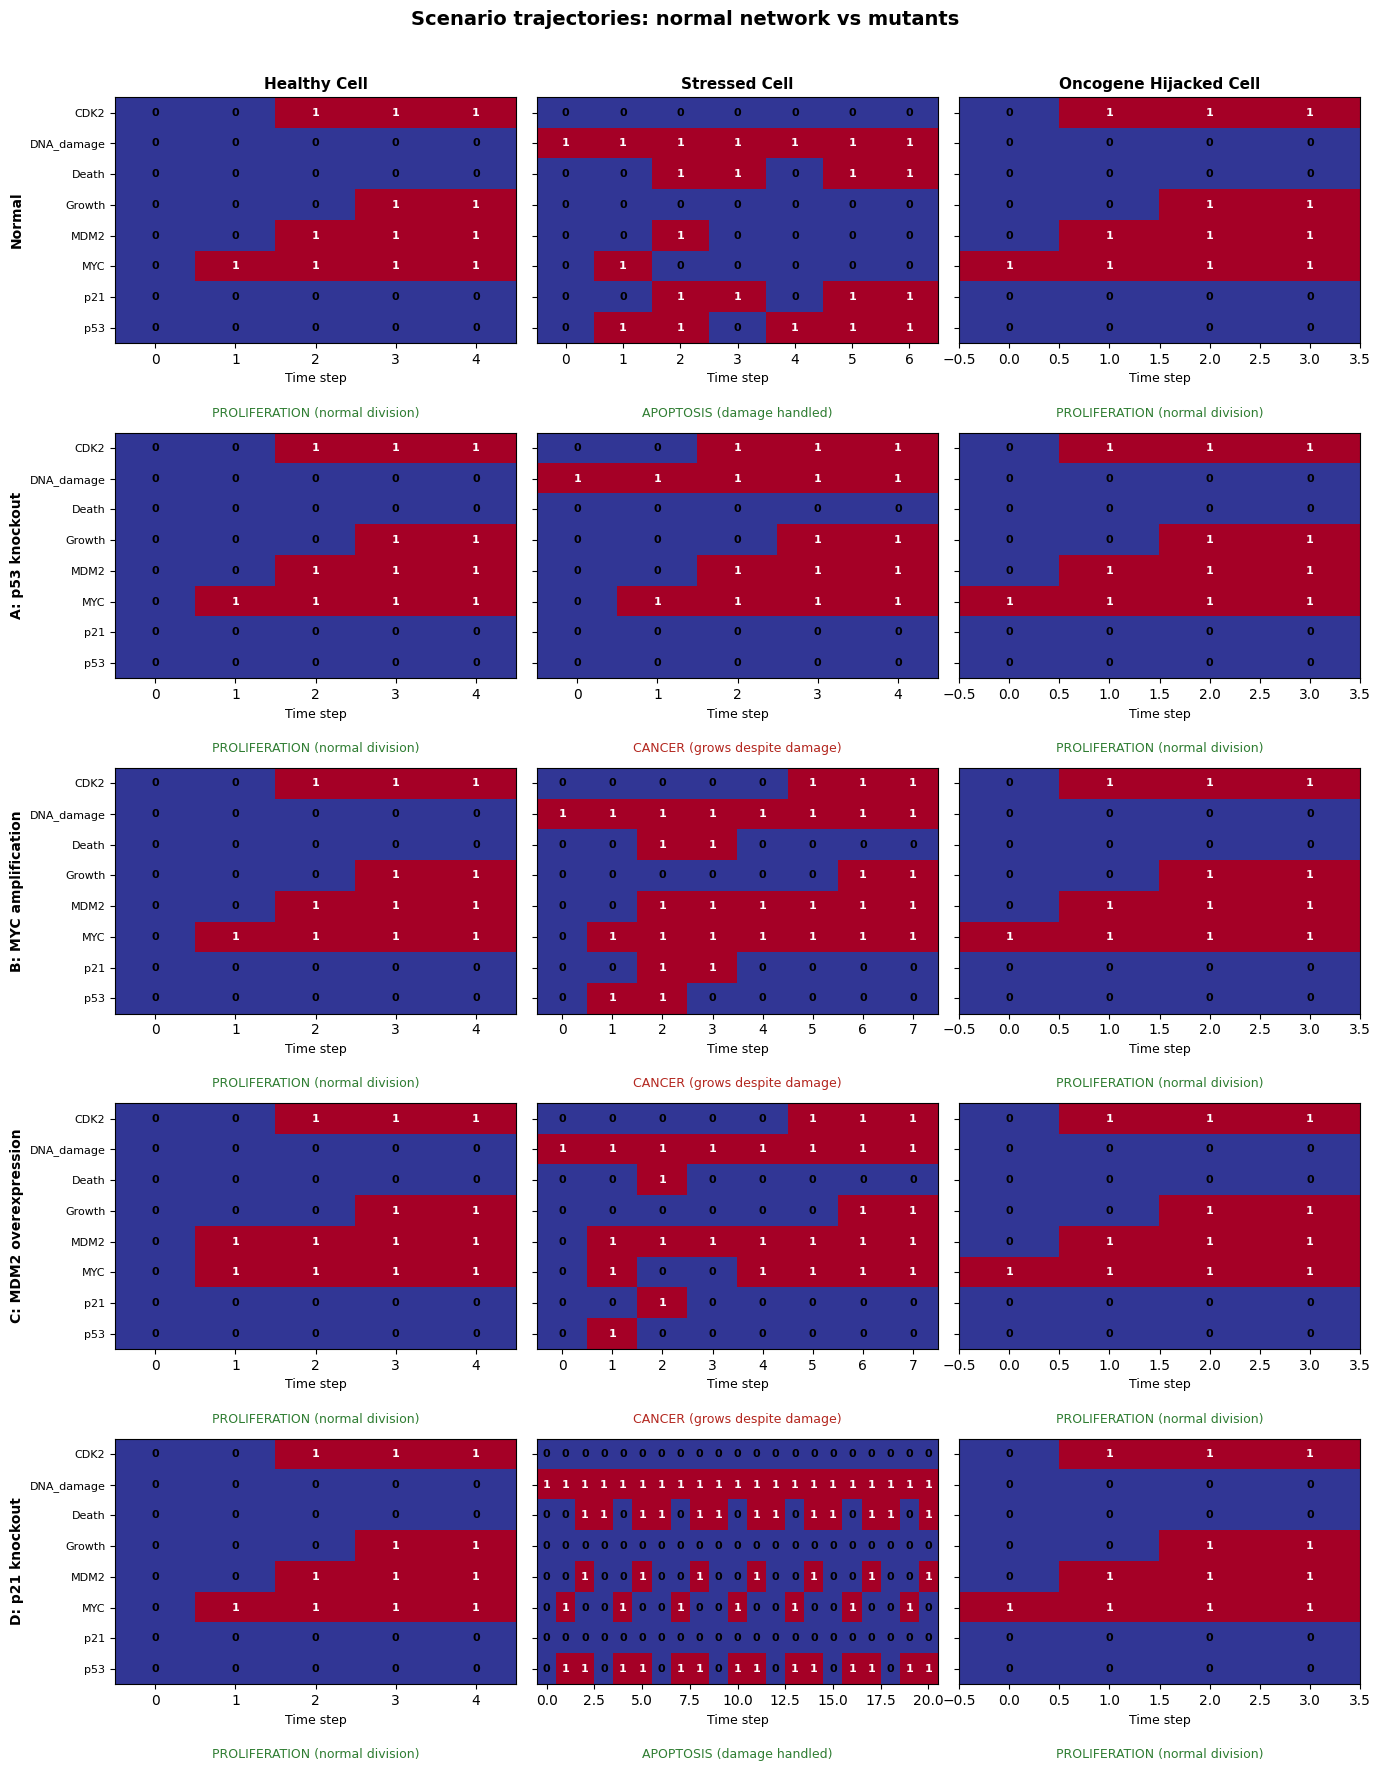

In [19]:
# Trajectory heatmaps: one row of panels per network, one panel per scenario.
n_net, n_scen = len(MUTATIONS), len(SCENARIOS)
fig, axes = plt.subplots(n_net, n_scen, figsize=(4.6 * n_scen, 3.6 * n_net), squeeze=False)

for r, net_name in enumerate(MUTATIONS):
    for c, scen_name in enumerate(SCENARIOS):
        ax = axes[r][c]
        traj = scenario_trajectories[net_name][scen_name]
        ax.imshow(traj.T, cmap='RdYlBu_r', aspect='auto', interpolation='nearest',
                  vmin=0, vmax=1)

        for t in range(traj.shape[0]):
            for n in range(len(NODE_NAMES)):
                value = int(traj.T[n, t])
                ax.text(t, n, value, ha='center', va='center', fontsize=8,
                        color='white' if value == 1 else 'black', fontweight='bold')

        ax.set_yticks(range(len(NODE_NAMES)))
        ax.set_yticklabels(NODE_NAMES if c == 0 else [], fontsize=8)
        ax.set_xlabel('Time step', fontsize=9)
        if c == 0:
            ax.set_ylabel(net_name, fontsize=10, fontweight='bold')
        ax.set_title(scen_name if r == 0 else '', fontsize=11, fontweight='bold')

        outcome = scenario_tables[net_name].query('scenario == @scen_name')['outcome'].iloc[0]
        ax.text(0.5, -0.30, outcome, transform=ax.transAxes, ha='center',
                fontsize=9, color='#b3261e' if outcome.startswith('CANCER') else '#2f7d32')

fig.suptitle('Scenario trajectories: normal network vs mutants', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 4. Attractor analysis

All 2⁸ = 256 states are used as starting points and followed until a state repeats. Detecting
the repeat, rather than comparing only the last two states, finds limit cycles as well as fixed
points.

**Cancer-like** means `Growth = 1` with `DNA_damage = 1` and `Death = 0` — growth despite
damage. Growth with no damage is ordinary proliferation and is counted separately; merging the
two would score even the healthy network at 53.1% cancerous.

In [20]:
def find_attractors(mutation, extra_overrides=None):
    """
    Exhaustively map the state space of one network.

    Returns
    -------
    attractors : list of tuple of state-tuples
        Each attractor as the cycle of states it consists of (length 1 = fixed point).
    basins : list of int
        How many of the 256 initial states converge to each attractor.
    """
    net = build_network(mutation, extra_overrides)
    rules = {n: net.rules[n]['function'] for n in NODE_NAMES}

    def step(state):
        return {n: int(bool(rules[n](state))) for n in NODE_NAMES}

    attractors, basins, index_of = [], [], {}

    for bits in product([0, 1], repeat=len(NODE_NAMES)):
        state = dict(zip(NODE_NAMES, bits))
        path, first_seen = [], {}
        key = tuple(state[n] for n in NODE_NAMES)

        # Walk forward until a state repeats; everything from that repeat on is the attractor.
        while key not in first_seen:
            first_seen[key] = len(path)
            path.append(key)
            state = step(state)
            key = tuple(state[n] for n in NODE_NAMES)

        cycle = path[first_seen[key]:]
        # Rotate to a canonical starting point so the same cycle is never counted twice.
        offset = min(range(len(cycle)), key=lambda k: cycle[k:] + cycle[:k])
        canonical = tuple(cycle[offset:] + cycle[:offset])

        if canonical not in index_of:
            index_of[canonical] = len(attractors)
            attractors.append(canonical)
            basins.append(0)
        basins[index_of[canonical]] += 1

    return attractors, basins


def attractor_table(mutation, extra_overrides=None):
    """One row per attractor: type, basin size, node states and biological fate."""
    attractors, basins = find_attractors(mutation, extra_overrides)
    rows = []
    for attractor, basin in zip(attractors, basins):
        # For a cycle, a node counts as ON if it is ON at any point in the cycle.
        merged = {n: max(dict(zip(NODE_NAMES, s))[n] for s in attractor) for n in NODE_NAMES}
        rows.append({
            'attractor_type': 'fixed point' if len(attractor) == 1 else f'cycle (length {len(attractor)})',
            'basin_states': basin,
            'basin_percent': round(100 * basin / 256, 1),
            **{n: merged[n] for n in ['DNA_damage', 'p53', 'MYC', 'MDM2', 'p21', 'CDK2', 'Growth', 'Death']},
            'fate': fate_label(merged),
        })
    return pd.DataFrame(rows).sort_values('basin_states', ascending=False).reset_index(drop=True)


attractor_tables = {}
for name in MUTATIONS:
    attractor_tables[name] = attractor_table(name)
    print(f"\n=== {name} — {len(attractor_tables[name])} attractor(s) ===")
    display(attractor_tables[name])


=== Normal — 3 attractor(s) ===


,attractor_type,basin_states,basin_percent,DNA_damage,p53,MYC,MDM2,p21,CDK2,Growth,Death,fate
0,fixed point,128,50.0,0,0,1,1,0,1,1,0,PROLIFERATION (normal division)
1,fixed point,120,46.9,1,1,0,0,1,0,0,1,APOPTOSIS (damage handled)
2,fixed point,8,3.1,1,0,1,1,0,1,1,0,CANCER (grows despite damage)



=== A: p53 knockout — 2 attractor(s) ===


,attractor_type,basin_states,basin_percent,DNA_damage,p53,MYC,MDM2,p21,CDK2,Growth,Death,fate
0,fixed point,128,50.0,0,0,1,1,0,1,1,0,PROLIFERATION (normal division)
1,fixed point,128,50.0,1,0,1,1,0,1,1,0,CANCER (grows despite damage)



=== B: MYC amplification — 2 attractor(s) ===


,attractor_type,basin_states,basin_percent,DNA_damage,p53,MYC,MDM2,p21,CDK2,Growth,Death,fate
0,fixed point,128,50.0,0,0,1,1,0,1,1,0,PROLIFERATION (normal division)
1,fixed point,128,50.0,1,0,1,1,0,1,1,0,CANCER (grows despite damage)



=== C: MDM2 overexpression — 2 attractor(s) ===


,attractor_type,basin_states,basin_percent,DNA_damage,p53,MYC,MDM2,p21,CDK2,Growth,Death,fate
0,fixed point,128,50.0,0,0,1,1,0,1,1,0,PROLIFERATION (normal division)
1,fixed point,128,50.0,1,0,1,1,0,1,1,0,CANCER (grows despite damage)



=== D: p21 knockout — 5 attractor(s) ===


,attractor_type,basin_states,basin_percent,DNA_damage,p53,MYC,MDM2,p21,CDK2,Growth,Death,fate
0,fixed point,128,50.0,0,0,1,1,0,1,1,0,PROLIFERATION (normal division)
1,cycle (length 3),56,21.9,1,1,1,1,0,0,0,1,APOPTOSIS (damage handled)
2,cycle (length 3),40,15.6,1,1,1,1,0,1,0,1,APOPTOSIS (damage handled)
3,fixed point,24,9.4,1,1,0,0,0,0,0,1,APOPTOSIS (damage handled)
4,fixed point,8,3.1,1,0,1,1,0,1,1,0,CANCER (grows despite damage)


In [21]:
# Collapse the attractor tables into one comparison, grouped by fate.
FATES = ['CANCER (grows despite damage)', 'APOPTOSIS (damage handled)',
         'PROLIFERATION (normal division)', 'QUIESCENT / other']

summary_rows = []
for name, table in attractor_tables.items():
    by_fate = table.groupby('fate')['basin_states'].sum()
    summary_rows.append({
        'network': name,
        'n_attractors': len(table),
        'n_cycles': int((table['attractor_type'] != 'fixed point').sum()),
        **{f.split(' (')[0].lower(): int(by_fate.get(f, 0)) for f in FATES},
    })

comparison = pd.DataFrame(summary_rows)
for col in ['cancer', 'apoptosis', 'proliferation', 'quiescent / other']:
    comparison[f'{col}_%'] = (100 * comparison[col] / 256).round(1)

print("Basin of attraction, in states out of 256:")
display(comparison)

Basin of attraction, in states out of 256:


,network,n_attractors,n_cycles,cancer,apoptosis,proliferation,quiescent / other,cancer_%,apoptosis_%,proliferation_%,quiescent / other_%
0,Normal,3,0,8,120,128,0,3.1,46.9,50.0,0.0
1,A: p53 knockout,2,0,128,0,128,0,50.0,0.0,50.0,0.0
2,B: MYC amplification,2,0,128,0,128,0,50.0,0.0,50.0,0.0
3,C: MDM2 overexpression,2,0,128,0,128,0,50.0,0.0,50.0,0.0
4,D: p21 knockout,5,2,8,120,128,0,3.1,46.9,50.0,0.0


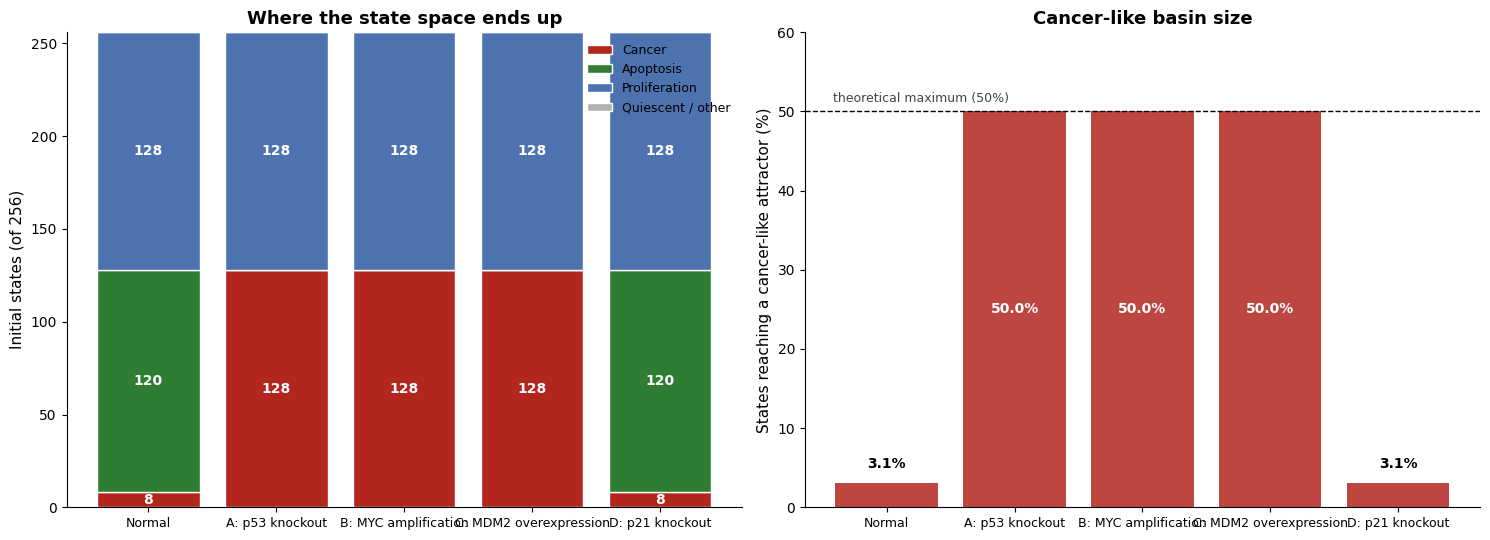

In [22]:
# Stacked bars: where does the state space go, for each network?
fig, (ax_stack, ax_cancer) = plt.subplots(1, 2, figsize=(15, 5.5))

fate_cols = ['cancer', 'apoptosis', 'proliferation', 'quiescent / other']
fate_colours = ['#b3261e', '#2f7d32', '#4C72B0', '#b0b0b0']

bottom = np.zeros(len(comparison))
for col, colour in zip(fate_cols, fate_colours):
    values = comparison[col].values
    ax_stack.bar(comparison['network'], values, bottom=bottom,
                 label=col.capitalize(), color=colour, edgecolor='white')
    for x, (v, b) in enumerate(zip(values, bottom)):
        if v > 0:
            ax_stack.text(x, b + v / 2, f'{v}', ha='center', va='center',
                          color='white', fontweight='bold', fontsize=10)
    bottom += values

ax_stack.set_ylabel('Initial states (of 256)', fontsize=11)
ax_stack.set_title('Where the state space ends up', fontsize=13, fontweight='bold')
ax_stack.legend(frameon=False, fontsize=9)
ax_stack.tick_params(axis='x', labelsize=9)
ax_stack.spines[['top', 'right']].set_visible(False)

bars = ax_cancer.bar(comparison['network'], comparison['cancer_%'], color='#b3261e', alpha=0.85)
ax_cancer.axhline(50, color='black', linestyle='--', linewidth=1)
ax_cancer.text(-0.42, 50.8, 'theoretical maximum (50%)',
               ha='left', va='bottom', fontsize=9, color='#444444')
for bar, value in zip(bars, comparison['cancer_%']):
    ax_cancer.text(bar.get_x() + bar.get_width() / 2,
                   value / 2 if value > 10 else value + 1.5, f'{value}%',
                   ha='center', va='center' if value > 10 else 'bottom',
                   fontweight='bold', color='white' if value > 10 else 'black')
ax_cancer.set_ylim(0, 60)
ax_cancer.set_ylabel('States reaching a cancer-like attractor (%)', fontsize=11)
ax_cancer.set_title('Cancer-like basin size', fontsize=13, fontweight='bold')
ax_cancer.tick_params(axis='x', labelsize=9)
ax_cancer.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## 5. Rescue experiment

A and B give identical basin sizes, so basin size cannot rank them. An MDM2 inhibitor (the
nutlin drug class) is added as one further override, `MDM2 = False`, on top of each network.
If p53 is only being suppressed, apoptosis should return; if p53 is gone, nothing changes.

In [23]:
# Simulate an MDM2 inhibitor as an additional rule override on top of each network.
MDM2_INHIBITOR = [('MDM2', lambda s: False, "MDM2 = BLOCKED by inhibitor (always OFF)")]

rescue_rows = []
for name in MUTATIONS:
    for drug_label, overrides in [('untreated', None), ('+ MDM2 inhibitor', MDM2_INHIBITOR)]:
        table = attractor_table(name, overrides)
        by_fate = table.groupby('fate')['basin_states'].sum()
        rescue_rows.append({
            'network': name,
            'treatment': drug_label,
            'cancer_states': int(by_fate.get('CANCER (grows despite damage)', 0)),
            'apoptosis_states': int(by_fate.get('APOPTOSIS (damage handled)', 0)),
        })

rescue = pd.DataFrame(rescue_rows)
rescue['cancer_%'] = (100 * rescue['cancer_states'] / 256).round(1)
rescue['apoptosis_%'] = (100 * rescue['apoptosis_states'] / 256).round(1)

pivot = rescue.pivot(index='network', columns='treatment', values='cancer_%')
pivot['rescued?'] = np.where(pivot['+ MDM2 inhibitor'] < pivot['untreated'], 'YES', 'NO')

print("Cancer-like basin, before and after simulated MDM2 inhibition:")
display(pivot)
print()
display(rescue)

Cancer-like basin, before and after simulated MDM2 inhibition:


treatment,+ MDM2 inhibitor,untreated,rescued?
network,,,
A: p53 knockout,50.0,50.0,NO
B: MYC amplification,0.0,50.0,YES
C: MDM2 overexpression,0.0,50.0,YES
D: p21 knockout,0.0,3.1,YES
Normal,0.0,3.1,YES


,network,treatment,cancer_states,apoptosis_states,cancer_%,apoptosis_%
0,Normal,untreated,8,120,3.1,46.9
1,Normal,+ MDM2 inhibitor,0,128,0.0,50.0
2,A: p53 knockout,untreated,128,0,50.0,0.0
3,A: p53 knockout,+ MDM2 inhibitor,128,0,50.0,0.0
4,B: MYC amplification,untreated,128,0,50.0,0.0
5,B: MYC amplification,+ MDM2 inhibitor,0,128,0.0,50.0
6,C: MDM2 overexpression,untreated,128,0,50.0,0.0
7,C: MDM2 overexpression,+ MDM2 inhibitor,0,128,0.0,50.0
8,D: p21 knockout,untreated,8,120,3.1,46.9
9,D: p21 knockout,+ MDM2 inhibitor,0,128,0.0,50.0


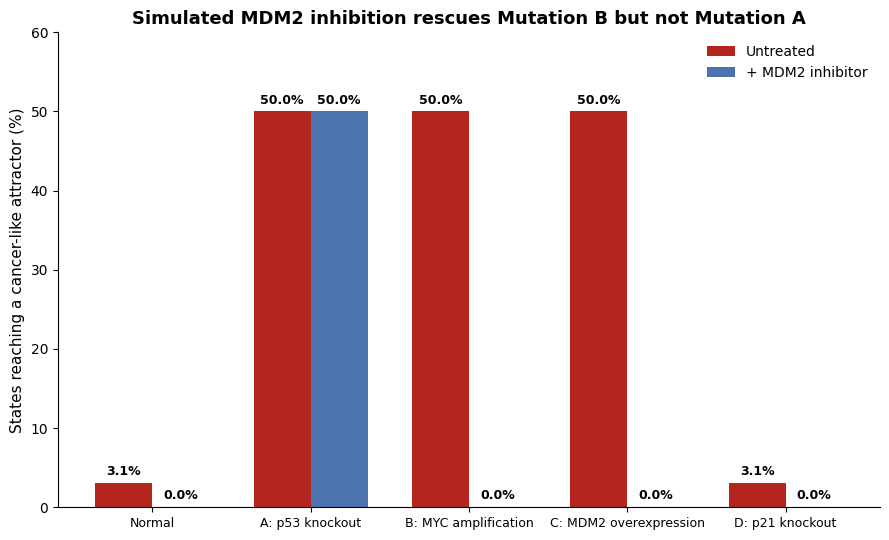

In [24]:
# Paired bars: untreated vs treated, per network.
fig, ax = plt.subplots(figsize=(9, 5.5))

networks = list(MUTATIONS)
x = np.arange(len(networks))
width = 0.36

untreated = [rescue.query('network == @n and treatment == "untreated"')['cancer_%'].iloc[0] for n in networks]
treated = [rescue.query('network == @n and treatment == "+ MDM2 inhibitor"')['cancer_%'].iloc[0] for n in networks]

ax.bar(x - width / 2, untreated, width, label='Untreated', color='#b3261e')
ax.bar(x + width / 2, treated, width, label='+ MDM2 inhibitor', color='#4C72B0')

for xi, (u, t) in enumerate(zip(untreated, treated)):
    ax.text(xi - width / 2, u + 1, f'{u}%', ha='center', fontweight='bold', fontsize=9)
    ax.text(xi + width / 2, t + 1, f'{t}%', ha='center', fontweight='bold', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(networks, fontsize=9)
ax.set_ylabel('States reaching a cancer-like attractor (%)', fontsize=11)
ax.set_title('Simulated MDM2 inhibition rescues Mutation B but not Mutation A',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 60)
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Results

- **Normal**: 3 fixed points, no cycles. 8/256 states (3.1%) cancer-like, 120 (46.9%) apoptosis,
  128 (50.0%) proliferation.
- **A, B and C**: 2 fixed points each, 128/256 (50.0%) cancer-like, apoptosis 0. A sixteen-fold
  increase in the cancer basin, and 50.0% is the ceiling — only half of all states have
  `DNA_damage = 1` at all.
- **D**:5 attractors , 8/256 (3.1%) cancer-like, 120 (46.9%) apoptosis, 128 (50.0%) proliferation — basin sizes identical to the normal, but reached through a different attractor structure. Two of the five attractors are 3-state limit cycles (21.9% and 15.6%), which appear in no other network. Because p53 is untouched, DNA-damaged cells can still die — only the same 3.1% of states that bypass the p53/MDM2 switch become cancer-like.
- **Stressed Cell scenario**: normal kills the cell in 6 steps; A reaches cancer in 4, B and C both in 7, and D never becomes cancerous, instead committing to aptosis after 20 steps.
  B fires an abortive response first (p53 ON at steps 1–2, Death ON at steps 2–3) before MYC
  drives MDM2 high enough to shut p53 down. A never responds at all. C is suppressed from step 1 because MDM2 is overexpressed directly, so p53 never fires. For D the cell-cycle brake (p21) is missing, so CDK2 and MYC delay but do not prevent apoptotic commitment.
- **Rescue**: MDM2 inhibition takes B and C from 50.0% to 0.0% cancer-like states and D from 3.1% to 0.0%, restoring the apoptotic basin to 128 states in each case. On A it changes nothing (50.0% → 50.0%). B and C suppresses p53 through an intact edge; A
  deletes it.
- **Why A, B and C behave identically, but D differently**: p53 and MYC sit in a positive feedback loop
  (p53 ⊣ MYC → MDM2 ⊣ p53). Each of these mutations pins one arm of the same switch. D leaves the switch intact and instead removes the downstream effector p21, so p53 can still trigger death; the result is a normal sized cancer basin (3.1%) but a different attractor structure with two limit cycles that neither the normal nor any of the other mutants produces.